<a href="https://colab.research.google.com/github/matheus00M7/mission_control_ai_gs/blob/main/mission_control_ai_gs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
# ============================================================
# CÉLULA 1 — INSTALAÇÃO DO OLLAMA NO GOOGLE COLAB
# ============================================================

!apt-get update -qq
!apt-get install -y zstd

!curl -fsSL https://ollama.com/install.sh | sh

!pip install ollama -q

print("Instalação finalizada.")

^C
^C
>>> Cleaning up old version at /usr/local/lib/ollama
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.
Instalação finalizada.


In [2]:
# ============================================================
# CÉLULA 2 — INICIAR OLLAMA E BAIXAR MODELO
# ============================================================

import time
import requests
import subprocess

# Encerra qualquer instância antiga do Ollama para evitar conflito
!pkill ollama || true

# Inicia o servidor Ollama em segundo plano usando nohup
!nohup ollama serve > ollama.log 2>&1 &

# Aguarda o servidor iniciar
time.sleep(10)

# Verifica se o servidor está respondendo
try:
    resposta_servidor = requests.get("http://127.0.0.1:11434/api/tags", timeout=5)
    print("Servidor Ollama está rodando.")
except Exception as erro:
    print("Atenção: o servidor Ollama ainda não respondeu.")
    print(erro)

# Baixa o modelo recomendado para o projeto
!ollama pull llama3.2:1b

print("Modelo carregado.")


Servidor Ollama está rodando.

Modelo carregado.


In [4]:
# ============================================================
# CÉLULA 3 — TESTE RÁPIDO DA IA
# ============================================================

import ollama

resposta = ollama.chat(
    model="llama3.2:1b",
    messages=[
        {
            "role": "system",
            "content": "Você é uma IA de controle de missão espacial. Responda de forma curta."
        },
        {
            "role": "user",
            "content": "Energia 18%, temperatura 95°C e comunicação instável. Qual o risco?"
        }
    ],
    options={
        "temperature": 0.2,
        "num_predict": 60
    }
)

print(resposta["message"]["content"])

Risco: Falta de coordenação e comunicação entre os componentes da equipe, levando a uma perda de controle e potencialmente à queda do veículo.


In [5]:
# ============================================================
# CÉLULA 4 — CONFIGURAÇÕES DO PROJETO
# GLOBAL SOLUTION 2026.1 — PROMPT AND ARTIFICIAL INTELLIGENCE
# ============================================================

import ollama
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import os

MODELO_IA = "llama3.2:1b"

SYSTEM_PROMPT = """
Você é uma IA de controle de missão espacial chamada Mission Control AI.

Sua função é analisar dados operacionais simulados de uma missão espacial experimental.
Você deve avaliar temperatura, energia, comunicação, oxigênio, radiação e status dos módulos.

Responda de forma objetiva, como um sistema de apoio à decisão.
Sempre apresente:
1. Nível geral de risco da missão
2. Principais problemas detectados
3. Possíveis consequências operacionais
4. Ações recomendadas para a equipe de controle

Não invente dados novos. Analise apenas os dados recebidos.
"""

print("Configurações carregadas.")

Configurações carregadas.


In [6]:
# ============================================================
# CÉLULA 5 — CENÁRIOS SIMULADOS DA MISSÃO
# ============================================================

cenarios_missao = [
    {
        "nome": "Cenário Normal",
        "temperatura": 24,
        "energia": 82,
        "comunicacao": "estável",
        "oxigenio": 96,
        "radiacao": 0.3,
        "status_modulo": "operacional"
    },
    {
        "nome": "Cenário de Atenção",
        "temperatura": 66,
        "energia": 42,
        "comunicacao": "estável",
        "oxigenio": 92,
        "radiacao": 0.8,
        "status_modulo": "atenção"
    },
    {
        "nome": "Cenário Crítico",
        "temperatura": 95,
        "energia": 18,
        "comunicacao": "instável",
        "oxigenio": 71,
        "radiacao": 2.8,
        "status_modulo": "crítico"
    }
]

print("Cenários simulados carregados.")

Cenários simulados carregados.


In [7]:
# ============================================================
# CÉLULA 6 — FUNÇÕES PRINCIPAIS DO SISTEMA
# ============================================================

def gerar_alertas(dados):
    alertas = []
    acoes = []

    temperatura = dados["temperatura"]
    energia = dados["energia"]
    comunicacao = dados["comunicacao"]
    oxigenio = dados["oxigenio"]
    radiacao = dados["radiacao"]

    if temperatura >= 85:
        alertas.append("Temperatura crítica detectada no módulo.")
        acoes.append("Ativar sistema de resfriamento de emergência.")
    elif temperatura >= 65:
        alertas.append("Temperatura acima do ideal.")
        acoes.append("Monitorar aquecimento e reduzir carga dos sistemas.")

    if energia <= 20:
        alertas.append("Energia abaixo do nível mínimo seguro.")
        acoes.append("Ativar modo de economia de energia e desligar sistemas não essenciais.")
    elif energia <= 40:
        alertas.append("Energia em nível de atenção.")
        acoes.append("Reduzir consumo e priorizar sistemas vitais.")

    if comunicacao.lower() == "instável":
        alertas.append("Comunicação instável com a base.")
        acoes.append("Reiniciar canal de comunicação e priorizar envio de telemetria essencial.")
    elif comunicacao.lower() == "sem sinal":
        alertas.append("Perda total de comunicação com a base.")
        acoes.append("Ativar protocolo automático de reconexão.")

    if oxigenio <= 75:
        alertas.append("Oxigênio em nível crítico.")
        acoes.append("Verificar suporte de vida e reduzir consumo interno.")
    elif oxigenio <= 90:
        alertas.append("Oxigênio abaixo do nível ideal.")
        acoes.append("Monitorar sistema de suporte de vida.")

    if radiacao >= 2.5:
        alertas.append("Radiação elevada detectada.")
        acoes.append("Reforçar proteção do módulo e mover tripulação para área segura.")
    elif radiacao >= 1.0:
        alertas.append("Radiação acima do nível normal.")
        acoes.append("Continuar monitoramento e limitar exposição.")

    # Classificação simples e coerente para apresentação:
    # 0 alertas = NORMAL | 1 a 3 alertas = ATENÇÃO | 4 ou mais alertas = CRÍTICO
    if len(alertas) >= 4:
        nivel_risco = "CRÍTICO"
    elif len(alertas) >= 1:
        nivel_risco = "ATENÇÃO"
    else:
        nivel_risco = "NORMAL"

    return nivel_risco, alertas, acoes


def montar_prompt_usuario(dados, nivel_risco, alertas, acoes):
    texto_alertas = "\n".join(f"- {alerta}" for alerta in alertas) if alertas else "Nenhum alerta automático detectado."
    texto_acoes = "\n".join(f"- {acao}" for acao in acoes) if acoes else "Nenhuma ação emergencial necessária."

    prompt = f"""
Analise os dados abaixo de uma missão espacial simulada.

Nome do cenário: {dados["nome"]}
Horário da análise: {datetime.now().strftime("%d/%m/%Y %H:%M:%S")}

Dados operacionais:
- Temperatura do módulo: {dados["temperatura"]}°C
- Energia disponível: {dados["energia"]}%
- Comunicação com a base: {dados["comunicacao"]}
- Oxigênio interno: {dados["oxigenio"]}%
- Radiação externa: {dados["radiacao"]} mSv/h
- Status do módulo: {dados["status_modulo"]}

Resultado da lógica automática:
Nível de risco calculado: {nivel_risco}

Alertas automáticos:
{texto_alertas}

Ações automáticas recomendadas:
{texto_acoes}

Com base nesses dados, gere uma análise operacional curta, clara e objetiva.
"""
    return prompt


def garantir_ollama_ativo():
    import requests
    import subprocess
    import time

    try:
        requests.get("http://127.0.0.1:11434/api/tags", timeout=3)
        return True
    except Exception:
        print("Ollama não respondeu. Tentando reiniciar o servidor...")
        subprocess.Popen(
            ["ollama", "serve"],
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL
        )
        time.sleep(8)

        try:
            requests.get("http://127.0.0.1:11434/api/tags", timeout=5)
            print("Servidor Ollama reiniciado.")
            return True
        except Exception:
            return False


def consultar_ia(prompt_usuario):
    if not garantir_ollama_ativo():
        return "Erro: não foi possível conectar ao servidor Ollama. Rode novamente a Célula 2 e depois esta célula."

    try:
        resposta = ollama.chat(
            model=MODELO_IA,
            messages=[
                {
                    "role": "system",
                    "content": SYSTEM_PROMPT
                },
                {
                    "role": "user",
                    "content": prompt_usuario
                }
            ],
            options={
                "temperature": 0.2,
                "num_predict": 160
            }
        )

        return resposta["message"]["content"]

    except Exception as erro:
        return f"Erro ao consultar a IA: {erro}"


def exibir_status(dados, nivel_risco, alertas, acoes, analise_ia):
    print("=" * 70)
    print("                 MISSION CONTROL AI — STATUS DA MISSÃO")
    print("=" * 70)
    print(f"Cenário analisado     : {dados['nome']}")
    print(f"Data/Hora da análise  : {datetime.now().strftime('%d/%m/%Y %H:%M:%S')}")
    print("-" * 70)
    print(f"Temperatura do módulo : {dados['temperatura']}°C")
    print(f"Energia disponível    : {dados['energia']}%")
    print(f"Comunicação           : {dados['comunicacao']}")
    print(f"Oxigênio interno      : {dados['oxigenio']}%")
    print(f"Radiação externa      : {dados['radiacao']} mSv/h")
    print(f"Status do módulo      : {dados['status_modulo']}")
    print("-" * 70)
    print(f"NÍVEL GERAL DE RISCO  : {nivel_risco}")
    print("-" * 70)

    print("ALERTAS AUTOMÁTICOS:")
    if alertas:
        for alerta in alertas:
            print(f"- {alerta}")
    else:
        print("- Nenhum alerta detectado.")

    print("-" * 70)
    print("AÇÕES RECOMENDADAS:")
    if acoes:
        for acao in acoes:
            print(f"- {acao}")
    else:
        print("- Missão dentro dos parâmetros normais.")

    print("-" * 70)
    print("ANÁLISE DA IA:")
    print(analise_ia)
    print("=" * 70)


def executar_cenario(dados, usar_ia=True):
    nivel_risco, alertas, acoes = gerar_alertas(dados)

    if usar_ia:
        prompt_usuario = montar_prompt_usuario(dados, nivel_risco, alertas, acoes)
        analise_ia = consultar_ia(prompt_usuario)
    else:
        analise_ia = "IA não consultada neste cenário. Análise automática feita pelas regras lógicas do sistema."

    exibir_status(dados, nivel_risco, alertas, acoes, analise_ia)

    return {
        "cenário": dados["nome"],
        "temperatura": dados["temperatura"],
        "energia": dados["energia"],
        "comunicacao": dados["comunicacao"],
        "oxigenio": dados["oxigenio"],
        "radiacao": dados["radiacao"],
        "status_modulo": dados["status_modulo"],
        "nivel_risco": nivel_risco,
        "quantidade_alertas": len(alertas),
        "alertas": alertas,
        "acoes": acoes,
        "analise_ia": analise_ia
    }

print("Funções carregadas.")


Funções carregadas.


In [12]:
# ============================================================
# CÉLULA 7 — EXECUÇÃO RÁPIDA DOS CENÁRIOS
# ============================================================

resultados = []

for cenario in cenarios_missao:
    # Nesta célula, os cenários são avaliados apenas pelas regras lógicas.
    # A IA será demonstrada separadamente na Célula 10.
    resultado = executar_cenario(cenario, usar_ia=False)
    resultados.append(resultado)
    print("\n\n")

print("Todos os cenários foram executados com lógica automática.")

                 MISSION CONTROL AI — STATUS DA MISSÃO
Cenário analisado     : Cenário Normal
Data/Hora da análise  : 01/06/2026 22:25:14
----------------------------------------------------------------------
Temperatura do módulo : 24°C
Energia disponível    : 82%
Comunicação           : estável
Oxigênio interno      : 96%
Radiação externa      : 0.3 mSv/h
Status do módulo      : operacional
----------------------------------------------------------------------
NÍVEL GERAL DE RISCO  : NORMAL
----------------------------------------------------------------------
ALERTAS AUTOMÁTICOS:
- Nenhum alerta detectado.
----------------------------------------------------------------------
AÇÕES RECOMENDADAS:
- Missão dentro dos parâmetros normais.
----------------------------------------------------------------------
ANÁLISE DA IA:
IA não consultada neste cenário. Análise automática feita pelas regras lógicas do sistema.



                 MISSION CONTROL AI — STATUS DA MISSÃO
Cenário analisado

In [13]:
# ============================================================
# CÉLULA 8 — TABELA RESUMO DOS RESULTADOS
# ============================================================

df_resultados = pd.DataFrame([
    {
        "Cenário": r["cenário"],
        "Temperatura (°C)": r["temperatura"],
        "Energia (%)": r["energia"],
        "Comunicação": r["comunicacao"],
        "Oxigênio (%)": r["oxigenio"],
        "Radiação (mSv/h)": r["radiacao"],
        "Status": r["status_modulo"],
        "Nível de Risco": r["nivel_risco"],
        "Qtd. Alertas": r["quantidade_alertas"]
    }
    for r in resultados
])

df_resultados

,Cenário,Temperatura (°C),Energia (%),Comunicação,Oxigênio (%),Radiação (mSv/h),Status,Nível de Risco,Qtd. Alertas
0,Cenário Normal,24,82,estável,96,0.3,operacional,NORMAL,0
1,Cenário de Atenção,66,42,estável,92,0.8,atenção,ATENÇÃO,1
2,Cenário Crítico,95,18,instável,71,2.8,crítico,CRÍTICO,5


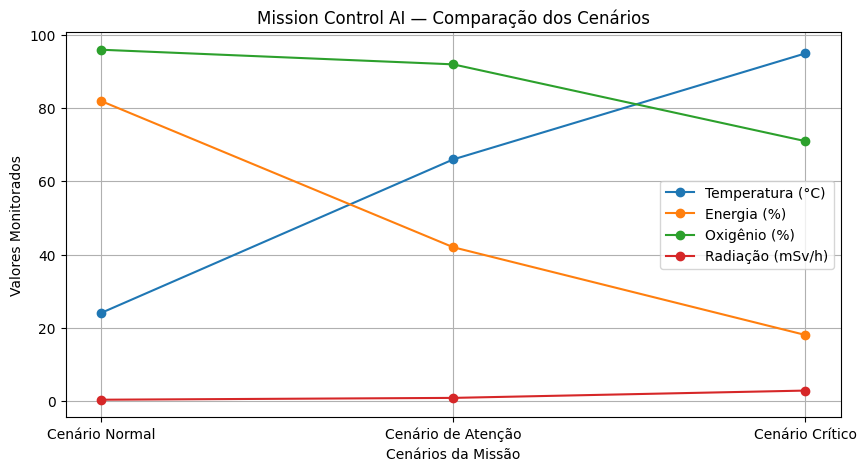

Gráfico salvo em: assets/grafico_cenarios.png


In [14]:
# ============================================================
# CÉLULA 9 — GRÁFICO DOS CENÁRIOS
# ============================================================

os.makedirs("assets", exist_ok=True)

plt.figure(figsize=(10, 5))

plt.plot(df_resultados["Cenário"], df_resultados["Temperatura (°C)"], marker="o", label="Temperatura (°C)")
plt.plot(df_resultados["Cenário"], df_resultados["Energia (%)"], marker="o", label="Energia (%)")
plt.plot(df_resultados["Cenário"], df_resultados["Oxigênio (%)"], marker="o", label="Oxigênio (%)")
plt.plot(df_resultados["Cenário"], df_resultados["Radiação (mSv/h)"], marker="o", label="Radiação (mSv/h)")

plt.title("Mission Control AI — Comparação dos Cenários")
plt.xlabel("Cenários da Missão")
plt.ylabel("Valores Monitorados")
plt.legend()
plt.grid(True)

plt.savefig("assets/grafico_cenarios.png", bbox_inches="tight")
plt.show()

print("Gráfico salvo em: assets/grafico_cenarios.png")

In [15]:
# ============================================================
# CÉLULA 10 — TESTE AO VIVO COM IA NO CENÁRIO CRÍTICO
# ============================================================

import ollama

cenario_personalizado = {
    "nome": "Teste Ao Vivo — Falha no Módulo de Energia",
    "temperatura": 88,
    "energia": 14,
    "comunicacao": "instável",
    "oxigenio": 73,
    "radiacao": 2.6,
    "status_modulo": "falha operacional crítica"
}

nivel_risco, alertas, acoes = gerar_alertas(cenario_personalizado)

print("=" * 70)
print("        MISSION CONTROL AI — TESTE AO VIVO COM IA")
print("=" * 70)
print(f"Cenário analisado     : {cenario_personalizado['nome']}")
print(f"Temperatura do módulo : {cenario_personalizado['temperatura']}°C")
print(f"Energia disponível    : {cenario_personalizado['energia']}%")
print(f"Comunicação           : {cenario_personalizado['comunicacao']}")
print(f"Oxigênio interno      : {cenario_personalizado['oxigenio']}%")
print(f"Radiação externa      : {cenario_personalizado['radiacao']} mSv/h")
print(f"Status do módulo      : {cenario_personalizado['status_modulo']}")
print("-" * 70)
print(f"NÍVEL GERAL DE RISCO  : {nivel_risco}")
print("-" * 70)

print("ALERTAS AUTOMÁTICOS:")
for alerta in alertas:
    print(f"- {alerta}")

print("-" * 70)
print("AÇÕES RECOMENDADAS:")
for acao in acoes:
    print(f"- {acao}")

print("-" * 70)
print("ANÁLISE DA IA:")

prompt_curto = f"""
Analise de forma curta a situação crítica abaixo:

Temperatura: {cenario_personalizado['temperatura']}°C
Energia: {cenario_personalizado['energia']}%
Comunicação: {cenario_personalizado['comunicacao']}
Oxigênio: {cenario_personalizado['oxigenio']}%
Radiação: {cenario_personalizado['radiacao']} mSv/h
Status: {cenario_personalizado['status_modulo']}

Diga o nível de risco e recomende ações imediatas.
"""

try:
    resposta = ollama.chat(
        model="llama3.2:1b",
        messages=[
            {
                "role": "system",
                "content": "Você é uma IA de controle de missão espacial. Responda de forma curta e objetiva."
            },
            {
                "role": "user",
                "content": prompt_curto
            }
        ],
        options={
            "temperature": 0.2,
            "num_predict": 80
        }
    )

    print(resposta["message"]["content"])

except Exception as erro:
    print("A IA não respondeu no momento.")
    print("Erro:", erro)

print("=" * 70)

        MISSION CONTROL AI — TESTE AO VIVO COM IA
Cenário analisado     : Teste Ao Vivo — Falha no Módulo de Energia
Temperatura do módulo : 88°C
Energia disponível    : 14%
Comunicação           : instável
Oxigênio interno      : 73%
Radiação externa      : 2.6 mSv/h
Status do módulo      : falha operacional crítica
----------------------------------------------------------------------
NÍVEL GERAL DE RISCO  : CRÍTICO
----------------------------------------------------------------------
ALERTAS AUTOMÁTICOS:
- Temperatura crítica detectada no módulo.
- Energia abaixo do nível mínimo seguro.
- Comunicação instável com a base.
- Oxigênio em nível crítico.
- Radiação elevada detectada.
----------------------------------------------------------------------
AÇÕES RECOMENDADAS:
- Ativar sistema de resfriamento de emergência.
- Ativar modo de economia de energia e desligar sistemas não essenciais.
- Reiniciar canal de comunicação e priorizar envio de telemetria essencial.
- Verificar suporte 

In [18]:
# ============================================================
# CÉLULA 11 — EXPORTAR E BAIXAR RELATÓRIO DA MISSÃO
# ============================================================

from google.colab import files

nome_arquivo = "relatorio_mission_control_ai.txt"

with open(nome_arquivo, "w", encoding="utf-8") as arquivo:
    arquivo.write("MISSION CONTROL AI — RELATÓRIO DE MONITORAMENTO\n")
    arquivo.write("=" * 60 + "\n\n")

    for r in resultados:
        arquivo.write(f"Cenário: {r['cenário']}\n")
        arquivo.write(f"Temperatura: {r['temperatura']}°C\n")
        arquivo.write(f"Energia: {r['energia']}%\n")
        arquivo.write(f"Comunicação: {r['comunicacao']}\n")
        arquivo.write(f"Oxigênio: {r['oxigenio']}%\n")
        arquivo.write(f"Radiação: {r['radiacao']} mSv/h\n")
        arquivo.write(f"Status do módulo: {r['status_modulo']}\n")
        arquivo.write(f"Nível de risco: {r['nivel_risco']}\n")
        arquivo.write(f"Quantidade de alertas: {r['quantidade_alertas']}\n")

        arquivo.write("\nAlertas:\n")
        if r["alertas"]:
            for alerta in r["alertas"]:
                arquivo.write(f"- {alerta}\n")
        else:
            arquivo.write("- Nenhum alerta detectado.\n")

        arquivo.write("\nAções recomendadas:\n")
        if r["acoes"]:
            for acao in r["acoes"]:
                arquivo.write(f"- {acao}\n")
        else:
            arquivo.write("- Nenhuma ação emergencial necessária.\n")

        arquivo.write("\nAnálise da IA:\n")
        arquivo.write(r["analise_ia"])
        arquivo.write("\n\n" + "=" * 60 + "\n\n")

print(f"Relatório gerado com sucesso: {nome_arquivo}")

# Faz o download do arquivo para o seu computador
files.download(nome_arquivo)

Relatório gerado com sucesso: relatorio_mission_control_ai.txt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>